## 01_Data_Exploration.ipynb
### Author: M. Nicol
### Date: 4/1/2026
#### Purpose:

In [1]:
# Import libraries

import polars as pl
import numpy as np
import pandas as pd
import ast
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Imported libraries sucessfully...")

Imported libraries sucessfully...


In [2]:
# Define paths/load data

data_path = Path('..\data')
recipes_path = data_path / "RAW_recipes.csv"

if not recipes_path.exists():
   raise FileNotFoundError(f"File not found: {recipes_path}. Please download the dataset at https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions?resource=download and place it into the data folder.")
print(F"Loading dataset from: {recipes_path}")

df = pl.read_csv(recipes_path)
df.shape
df.head()

Loading dataset from: ..\data\RAW_recipes.csv


<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\admin\AppData\Local\Temp\ipykernel_19176\1088163006.py:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  data_path = Path('..\data')


name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
str,i64,i64,i64,str,str,str,i64,str,str,str,i64
"""arriba baked winter squash m…",137739,55,47892,"""2005-09-16""","""['60-minutes-or-less', 'time-t…","""[51.5, 0.0, 13.0, 0.0, 2.0, 0.…",11,"""['make a choice and proceed wi…","""autumn is my favorite time of …","""['winter squash', 'mexican sea…",7
"""a bit different breakfast piz…",31490,30,26278,"""2002-06-17""","""['30-minutes-or-less', 'time-t…","""[173.4, 18.0, 0.0, 17.0, 22.0,…",9,"""['preheat oven to 425 degrees …","""this recipe calls for the crus…","""['prepared pizza crust', 'saus…",6
"""all in the kitchen chili""",112140,130,196586,"""2005-02-25""","""['time-to-make', 'course', 'pr…","""[269.8, 22.0, 32.0, 48.0, 39.0…",6,"""['brown ground beef in large p…","""this modified version of 'mom'…","""['ground beef', 'yellow onions…",13
"""alouette potatoes""",59389,45,68585,"""2003-04-14""","""['60-minutes-or-less', 'time-t…","""[368.1, 17.0, 10.0, 2.0, 14.0,…",11,"""['place potatoes in a large po…","""this is a super easy, great ta…","""['spreadable cheese with garli…",11
"""amish tomato ketchup for can…",44061,190,41706,"""2002-10-25""","""['weeknight', 'time-to-make', …","""[352.9, 1.0, 337.0, 23.0, 3.0,…",5,"""['mix all ingredients& boil fo…","""my dh's amish mother raised hi…","""['tomato juice', 'apple cider …",8


In [3]:
# Column Names/DTypes
print(df.schema)

# Column Statistics
print(df.describe())

Schema({'name': String, 'id': Int64, 'minutes': Int64, 'contributor_id': Int64, 'submitted': String, 'tags': String, 'nutrition': String, 'n_steps': Int64, 'steps': String, 'description': String, 'ingredients': String, 'n_ingredients': Int64})
shape: (9, 13)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ name      ┆ id        ┆ minutes   ┆ … ┆ steps     ┆ descripti ┆ ingredien ┆ n_ingred │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ on        ┆ ts        ┆ ients    │
│ str       ┆ str       ┆ f64       ┆ f64       ┆   ┆ str       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆ str       ┆ str       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 231636    ┆ 231637.0  ┆ 231637.0  ┆ … ┆ 231637    ┆ 226658    ┆ 231637    ┆ 231637.0 │
│ null_coun ┆ 1         ┆ 0.0     

In [4]:
for i, row in enumerate(df.sample(5, seed=42).iter_rows(named=True), 1):
    print(f"\n=== Recipe {i}: {row['name']} ===")
    print(f"ID: {row['id']}, Minutes: {row['minutes']}")
    print(row['description'][:200] + "..." if row['description'] else "No description")
    
    try:
        ings = ast.literal_eval(row['ingredients'])
        print(f"Ingredients ({len(ings)}): {ings[:10]}")
    except:
        print(f"Ingredients (raw): {row['ingredients'][:300]}")
    
    print(f"Steps: {row['n_steps']}")


=== Recipe 1: slow cook potato kugel  gluten free ===
ID: 291971, Minutes: 335
potato kugel is always better the longer you bake it! so keep it in that oven!!! a good tip for potato kugel, is always to use a food processor - otherwise you end up with a gooey grey mess - and i do...
Ingredients (7): ['white potatoes', 'eggs', 'vegetable oil', 'onions', 'seasoning salt', 'pepper', 'garlic cloves']
Steps: 15

=== Recipe 2: duck  or chicken    chile mole tostadas ===
ID: 62084, Minutes: 140
this comes from an astonishingly talented chef, pablo jacinto, who is from the oaxaca region of mexico. he calls this mole de la suegra , mother-in-law's mole. the recipe is in two parts, but you coul...
Ingredients (24): ['dried negro chile', 'dried ancho chiles', 'olive oil', 'french bread', 'sesame seeds', 'tomatoes', 'onions', 'garlic', 'chicken stock', 'whole black peppercorns']
Steps: 35

=== Recipe 3: wisconsin dutch cabbage soup ===
ID: 330033, Minutes: 45
so easy to make and so delicious.  fro

In [5]:
import polars as pl
import ast

# Step 1: Create ingredients_list
df = df.with_columns(
    ingredients_list=pl.col("ingredients").map_elements(
        ast.literal_eval, return_dtype=pl.List(pl.Utf8)
    )
)

# Step 2: Create n_ingredients_parsed (length of each list)
df = df.with_columns(
    n_ingredients_parsed=pl.col("ingredients_list").list.len()
)


In [6]:
# Basic stats on number of ingredients
stats = df.select([
    pl.col("n_ingredients_parsed").mean().alias("avg_ingredients"),
    pl.col("n_ingredients_parsed").min().alias("min_ingredients"),
    pl.col("n_ingredients_parsed").max().alias("max_ingredients"),
    pl.col("n_ingredients_parsed").median().alias("median_ingredients")
])

print(stats)

shape: (1, 4)
┌─────────────────┬─────────────────┬─────────────────┬────────────────────┐
│ avg_ingredients ┆ min_ingredients ┆ max_ingredients ┆ median_ingredients │
│ ---             ┆ ---             ┆ ---             ┆ ---                │
│ f64             ┆ u32             ┆ u32             ┆ f64                │
╞═════════════════╪═════════════════╪═════════════════╪════════════════════╡
│ 9.051153        ┆ 1               ┆ 43              ┆ 9.0                │
└─────────────────┴─────────────────┴─────────────────┴────────────────────┘


In [7]:
# Most common ingredients (flattened)
all_ingredients = df.select(
    pl.col("ingredients_list").explode()
).to_series()

top_ingredients = all_ingredients.value_counts().sort("count", descending=True).head(20)

print("=== Top 20 Most Common Ingredients ===")
print(top_ingredients)

=== Top 20 Most Common Ingredients ===
shape: (20, 2)
┌──────────────────┬───────┐
│ ingredients_list ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ salt             ┆ 85746 │
│ butter           ┆ 54975 │
│ sugar            ┆ 44535 │
│ onion            ┆ 39065 │
│ water            ┆ 34914 │
│ …                ┆ …     │
│ egg              ┆ 17304 │
│ salt and pepper  ┆ 15415 │
│ parmesan cheese  ┆ 14807 │
│ lemon juice      ┆ 14233 │
│ baking soda      ┆ 14099 │
└──────────────────┴───────┘


C:\Users\admin\AppData\Local\Temp\ipykernel_19176\2661179078.py:3: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  pl.col("ingredients_list").explode()


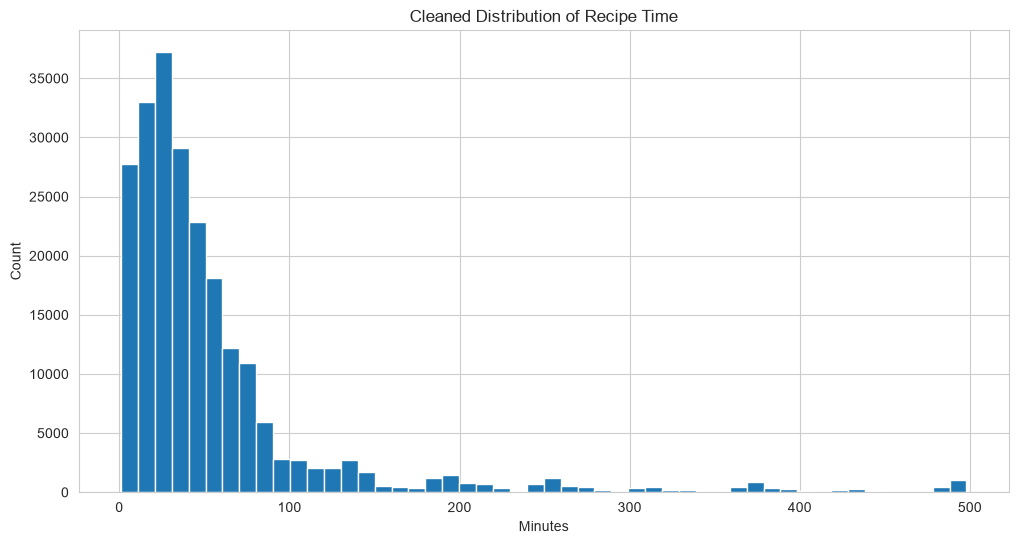

In [8]:
import matplotlib.pyplot as plt

df_clean = df.filter((df["minutes"] > 0) & (df["minutes"] < 500))

plt.figure()
plt.hist(df_clean["minutes"].to_list(), bins=50)
plt.title("Cleaned Distribution of Recipe Time")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

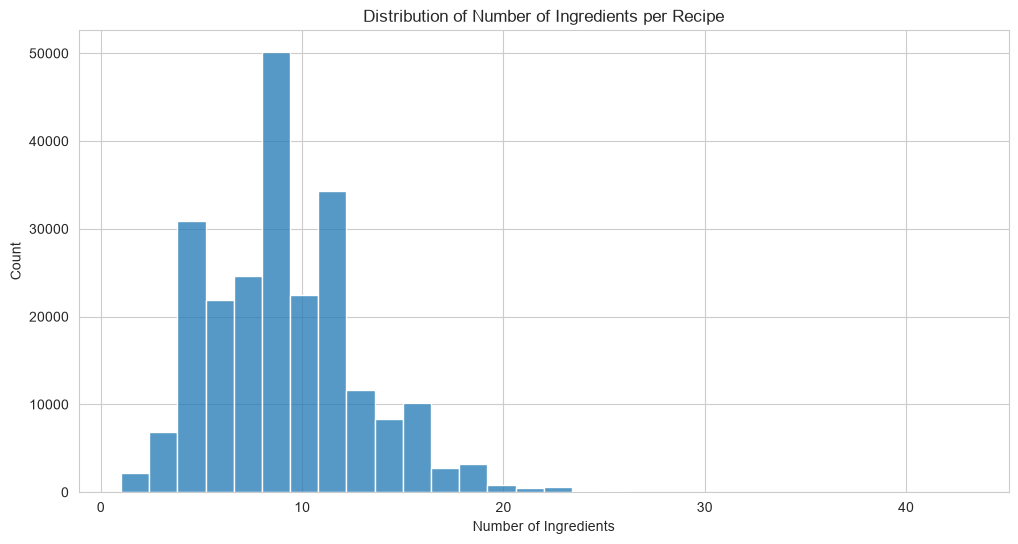

In [9]:
# Distribution of number of ingredients
plt.figure()
sns.histplot(df["n_ingredients_parsed"].to_numpy(), bins=30)
plt.title("Distribution of Number of Ingredients per Recipe")
plt.xlabel("Number of Ingredients")
plt.ylabel("Count")
plt.show()

Top 15 Most Common Recipe Tags:

Creating tags_list column...


C:\Users\admin\AppData\Local\Temp\ipykernel_19176\2787698429.py:15: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  df.select(pl.col("tags_list").explode().alias("tag"))


shape: (15, 2)
┌────────────────────┬────────┐
│ tag                ┆ count  │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ preparation        ┆ 230546 │
│ time-to-make       ┆ 225326 │
│ course             ┆ 218148 │
│ main-ingredient    ┆ 170446 │
│ dietary            ┆ 165091 │
│ …                  ┆ …      │
│ equipment          ┆ 70436  │
│ 60-minutes-or-less ┆ 69990  │
│ number-of-servings ┆ 58949  │
│ meat               ┆ 56042  │
│ 30-minutes-or-less ┆ 55077  │
└────────────────────┴────────┘


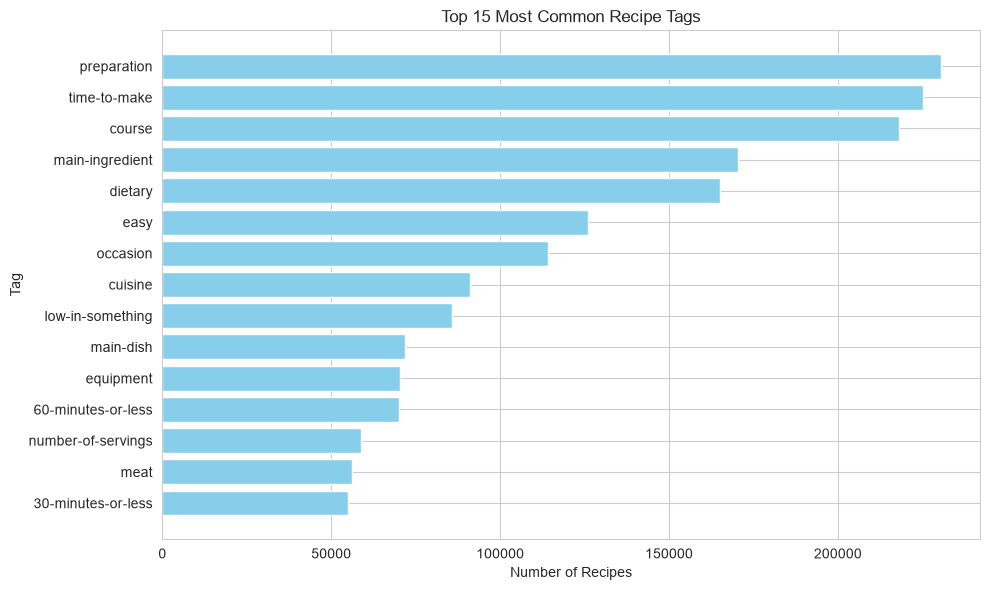

In [10]:
# Minimal Top 15 Most Common Tags (Fixed + Safe)
print("Top 15 Most Common Recipe Tags:\n")

# Ensure tags_list exists
if "tags_list" not in df.columns:
    print("Creating tags_list column...")
    df = df.with_columns(
        pl.col("tags")
          .map_elements(ast.literal_eval, return_dtype=pl.List(pl.Utf8))
          .alias("tags_list")
    )

# Now compute top tags
top_tags = (
    df.select(pl.col("tags_list").explode().alias("tag"))
      .group_by("tag")
      .agg(pl.len().alias("count"))
      .sort("count", descending=True)
      .head(15)
)

print(top_tags)

# Simple plot
tags = top_tags["tag"].to_list()
counts = top_tags["count"].to_list()

plt.figure(figsize=(10, 6))
plt.barh(tags, counts, color='skyblue')
plt.title("Top 15 Most Common Recipe Tags")
plt.xlabel("Number of Recipes")
plt.ylabel("Tag")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [11]:
# Nutrition is stored as string like "[calories, total_fat_pdv, ...]"
print("Sample nutrition value:")
print(df.select("nutrition").head(1).item())

Sample nutrition value:
[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]


In [12]:
# Quick parse example (you can expand this later)
def parse_nutrition(nut_str):
    try:
        return ast.literal_eval(nut_str)
    except:
        return [None] * 7

# For now, just show one example
print("\nExample parsed nutrition:", parse_nutrition(df["nutrition"][0]))


Example parsed nutrition: [51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]


In [13]:
# Save a small cleaned version for faster testing in other notebooks
clean_sample = df.sample(n=5000, seed=42)   # or keep full if your machine can handle it

clean_sample.write_parquet("../processed/recipes_sample.parquet")
print("Saved 5,000 recipe sample to ../processed/recipes_sample.parquet")

Saved 5,000 recipe sample to ../processed/recipes_sample.parquet
